# Audit a Dataset for Bias

In [42]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.algorithms.preprocessing import Reweighing
from aif360.metrics import ClassificationMetric
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from aif360.datasets import StructuredDataset

In [24]:
# 1. Load and preprocess data
df = pd.read_csv('compas-scores-two-years.CSV')  # Update path as needed

In [27]:
# Filter relevant columns and rows
df = df[['race', 'age', 'priors_count', 'decile_score', 'two_year_recid']].dropna()
df = df[df['race'].isin(['African-American', 'Caucasian'])]  # Focus on two largest groups

# Convert race to numerical values (0 for privileged group, 1 for unprivileged)
df['race'] = df['race'].map({'Caucasian': 0, 'African-American': 1})

In [28]:
# Convert to BinaryLabelDataset format
dataset = BinaryLabelDataset(
    df=df,
    label_names=['two_year_recid'],
    protected_attribute_names=['race'],
    favorable_label=0,
    unfavorable_label=1
)

In [29]:
# 2. Bias metrics calculation
privileged_group = [{'race': 0}]  # Caucasian
unprivileged_group = [{'race': 1}]  # African-American

metric = BinaryLabelDatasetMetric(
    dataset,
    unprivileged_groups=unprivileged_group,
    privileged_groups=privileged_group
)

print("Disparate Impact:", metric.disparate_impact())
print("Statistical Parity Difference:", metric.statistical_parity_difference())


Disparate Impact: 0.8009476242843179
Statistical Parity Difference: -0.12069679505498576


Text(0.5, 1.0, 'Risk Score Distribution by Race')

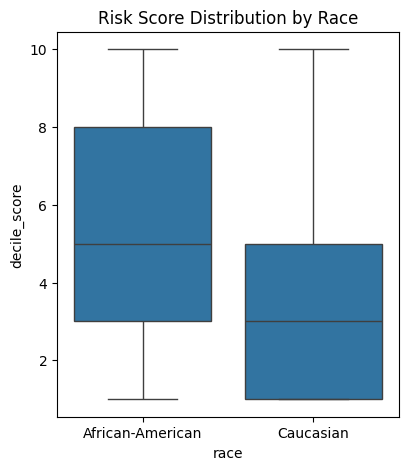

In [30]:
# 3. Visualizations
plt.figure(figsize=(15, 5))

# Disparity in scores
plt.subplot(1, 3, 1)
sns.boxplot(x=df['race'].map({0: 'Caucasian', 1: 'African-American'}),
            y='decile_score', data=df)
plt.title('Risk Score Distribution by Race')

In [31]:
# False positive/negative rates
# Split data and train model
X = pd.get_dummies(df.drop(['two_year_recid', 'race'], axis=1))
y = df['two_year_recid']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


After mitigation:
Disparate Impact: 1.0000000000000002
Statistical Parity Difference: 1.1102230246251565e-16


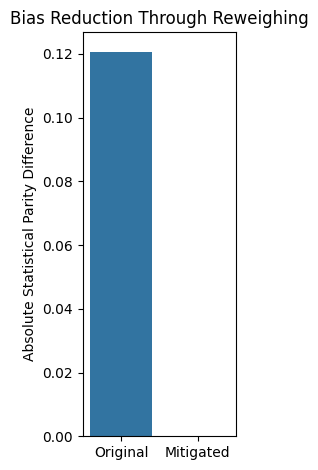

In [45]:
# 4. Mitigation with Reweighing
rw = Reweighing(unprivileged_groups=unprivileged_group,
               privileged_groups=privileged_group)
dataset_transformed = rw.fit_transform(dataset)

metric_transformed = BinaryLabelDatasetMetric(
    dataset_transformed,
    unprivileged_groups=unprivileged_group,
    privileged_groups=privileged_group
)

print("\nAfter mitigation:")
print("Disparate Impact:", metric_transformed.disparate_impact())
print("Statistical Parity Difference:", metric_transformed.statistical_parity_difference())

plt.subplot(1, 3, 3)
sns.barplot(x=['Original', 'Mitigated'],
            y=[abs(metric.statistical_parity_difference()),
               abs(metric_transformed.statistical_parity_difference())])
plt.title('Bias Reduction Through Reweighing')
plt.ylabel('Absolute Statistical Parity Difference')

plt.tight_layout()
plt.show()